# Clifford Volume Benchmark

This notebook runs the QCMet Clifford Volume benchmark on Aer, evaluates its stabilizer and destabilizer threshold criteria, and compares results across a small noise sweep.

## Import Benchmark and Analysis Dependencies

The setup below finds the repository root so the example also works when opened from a notebook server started in a subdirectory.

In [1]:
import importlib
import sys
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
from qiskit_aer.noise import NoiseModel, depolarizing_error

workspace_root = Path.cwd()
while not (workspace_root / "pyproject.toml").exists() and workspace_root != workspace_root.parent:
    workspace_root = workspace_root.parent

if not (workspace_root / "pyproject.toml").exists():
    raise FileNotFoundError("Could not locate the QCMet workspace root")

sys.path.insert(0, str(workspace_root))

from qcmet import AerSimulator
from qcmet.benchmarks.circuit_execution_quality_metrics import clifford_volume

CliffordVolume = importlib.reload(clifford_volume).CliffordVolume

## Define `clifford_volume` Benchmark Parameters

Use two qubits and a short depth for a quick local run. Each sampled Clifford generates measurements for the selected stabilizers and destabilizers.

In [2]:
n_qubits = 20
depth = 4
num_circuits = 4
num_measured_stabilizers = 4
num_shots = 512
seed = 42

## Initialize the Benchmark Runner

The helper keeps benchmark construction and execution settings together for the baseline and sweep.

In [3]:
def run_clifford_volume(
    qubits,
    depth,
    num_circuits,
    noise_probability=0.0,
    num_shots=num_shots,
    seed=seed,
):
    noise_model = NoiseModel()
    if noise_probability:
        error = depolarizing_error(noise_probability, 2)
        noise_model.add_all_qubit_quantum_error(error, ["cx", "swap"])

    benchmark = CliffordVolume(
        qubits=qubits,
        depth=depth,
        num_circuits=num_circuits,
        num_measured_stabilizers=num_measured_stabilizers,
        seed=seed,
    )
    benchmark.generate_circuits()
    benchmark.run(
        device=AerSimulator(
            method="stabilizer",
            noise_model=noise_model,
            seed_simulator=seed,
        ),
        num_shots=num_shots,
    )
    return benchmark.analyze()

## Execute a Single `clifford_volume` Run

Start noiseless. The output includes the individual and average threshold conditions, as well as the overall pass indicator.

In [4]:
baseline_result = run_clifford_volume(
    qubits=n_qubits,
    depth=depth,
    num_circuits=num_circuits,
)

{
    "passes": baseline_result["passes"],
    "average_stabilizers": baseline_result["average_stabilizer_expectation_values"],
    "average_destabilizers": baseline_result[
        "average_destabilizer_expectation_values"
    ],
    "stabilizer_average_pass": baseline_result["stabilizer_average_pass"],
    "destabilizer_average_pass": baseline_result["destabilizer_average_pass"],
}

{'passes': False,
 'average_stabilizers': [1.0, 1.0, 1.0, 1.0],
 'average_destabilizers': [-0.01171875, 0.0029296875, -0.01171875, 0.03515625],
 'stabilizer_average_pass': [True, True, True, True],
 'destabilizer_average_pass': [True, True, True, True]}

## Sweep Problem Sizes and Trial Counts

The sweep varies circuit depth and noise probability while keeping the problem small enough for a local example.

In [ ]:
depths = [2, 4, 6, 10, 20, 30, 40, 50]
noise_probabilities = [0.001, 0.01, 0.05]
sweep_results = []

for sweep_depth in depths:
    for noise_probability in noise_probabilities:
        result = run_clifford_volume(
            qubits=n_qubits,
            depth=sweep_depth,
            num_circuits=num_circuits,
            noise_probability=noise_probability,
        )

        stabilizer_means = np.array(
            result["average_stabilizer_expectation_values"], dtype=float
        )
        destabilizer_means = np.array(
            result["average_destabilizer_expectation_values"], dtype=float
        )
        stabilizer_stds = np.array(
            result["average_stabilizer_standard_deviations"], dtype=float
        )
        destabilizer_stds = np.array(
            result["average_destabilizer_standard_deviations"], dtype=float
        )
        stabilizer_individual = np.array(
            result["stabilizer_expectation_values"], dtype=float
        ).ravel()
        destabilizer_individual = np.array(
            result["destabilizer_expectation_values"], dtype=float
        ).ravel()
        stabilizer_individual_stds = np.array(
            result["stabilizer_standard_deviations"], dtype=float
        ).ravel()

        sweep_results.append(
            {
                "qubits": n_qubits,
                "depth": sweep_depth,
                "num_circuits": num_circuits,
                "noise_probability": noise_probability,
                "passes": result["passes"],
                "stabilizer_average": float(np.mean(stabilizer_means)),
                "destabilizer_average": float(np.mean(destabilizer_means)),
                "stabilizer_variance": float(np.mean(stabilizer_stds**2)),
                "destabilizer_variance": float(np.mean(destabilizer_stds**2)),
                "stabilizer_clifford_averages": stabilizer_means.tolist(),
                "destabilizer_clifford_averages": destabilizer_means.tolist(),
                "stabilizer_clifford_stds": stabilizer_stds.tolist(),
                "destabilizer_clifford_stds": destabilizer_stds.tolist(),
                "stabilizer_individual": stabilizer_individual.tolist(),
                "destabilizer_individual": destabilizer_individual.tolist(),
                "stabilizer_individual_std": stabilizer_individual_stds.tolist(),
            }
        )

## Collect Metrics into Tabular Results

A DataFrame makes it straightforward to compare parameter choices or save results for later use.

In [6]:
results_df = pd.DataFrame(sweep_results)
results_df.iloc[:, :10]

,qubits,depth,num_circuits,noise_probability,passes,stabilizer_average,destabilizer_average,stabilizer_variance,destabilizer_variance,stabilizer_clifford_averages
0,20,2,4,0.00,False,1.000000,0.014648,0.000000,0.000487,"[1.0, 1.0, 1.0, 1.0]"
1,20,2,4,0.01,True,0.991699,0.015625,0.000008,0.000487,"[0.9921875, 0.9990234375, 0.9833984375, 0.9921..."
2,20,2,4,0.05,True,0.968750,0.015625,0.000029,0.000487,"[0.9775390625, 0.98828125, 0.921875, 0.9873046..."
3,20,4,4,0.00,False,1.000000,0.003662,0.000000,0.000487,"[1.0, 1.0, 1.0, 1.0]"
4,20,4,4,0.01,True,0.980957,-0.015381,0.000018,0.000488,"[0.9794921875, 0.982421875, 0.9853515625, 0.97..."
5,20,4,4,0.05,True,0.907227,-0.014160,0.000085,0.000488,"[0.9072265625, 0.9169921875, 0.90625, 0.8984375]"
6,20,6,4,0.00,False,1.000000,0.000244,0.000000,0.000487,"[1.0, 1.0, 1.0, 1.0]"
7,20,6,4,0.01,True,0.977539,0.013672,0.000022,0.000487,"[0.9765625, 0.978515625, 0.98046875, 0.974609375]"
8,20,6,4,0.05,True,0.890625,0.007568,0.000100,0.000488,"[0.869140625, 0.8876953125, 0.916015625, 0.889..."
9,20,10,4,0.00,False,1.000000,0.025391,0.000000,0.000487,"[1.0, 1.0, 1.0, 1.0]"


## Plot Performance and Success Metrics

The first panel shows the stabilizer and destabilizer trends; the second shows whether every threshold condition passed.

First plot shows the average expectation value per circuit; averaging over all stabilizers/destabilizers for each circuit.\
Worst performing circuit shown by connected points and its $5\sigma$ deviation is shown in the shaded region.


Second plot shows the worst performing measurement overall for each circuit/stabilizer and its $2\sigma$ deviation over all shots.
\
This usually fails (meaning $<S_{ik}> - 2\sigma_{S_{ik}} > \tau_S$) first

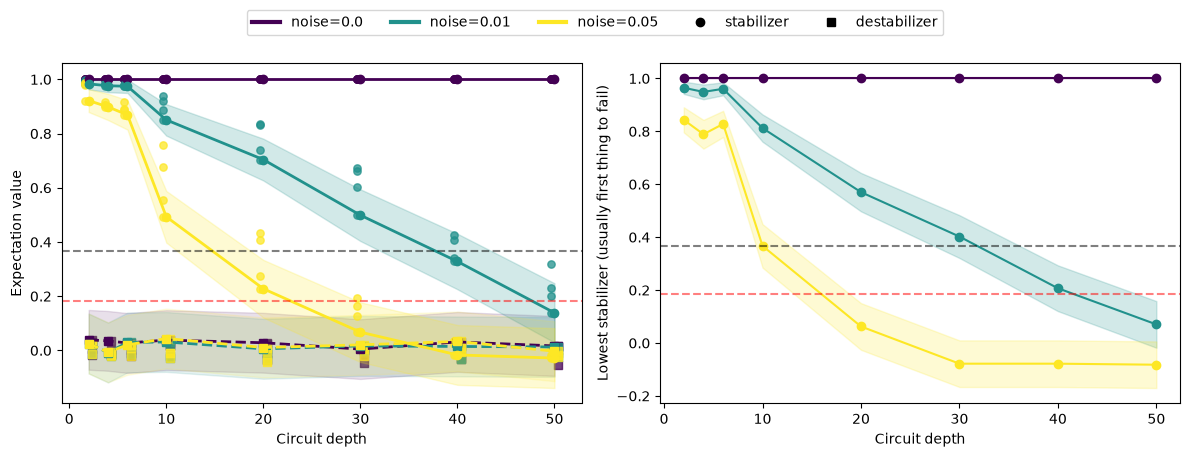

In [10]:
fig, (metric_axis, min_axis) = plt.subplots(1, 2, figsize=(12, 4.5))

noise_levels = sorted(results_df["noise_probability"].unique())
denom = max(len(noise_levels) - 1, 1)
color_map = {
    noise: plt.cm.viridis(index / denom)
    for index, noise in enumerate(noise_levels)
}

for noise_probability in noise_levels:
    group = results_df[results_df["noise_probability"] == noise_probability].sort_values(
        "depth"
    )
    depths_plot = group["depth"].to_numpy(dtype=float)
    color = color_map[noise_probability]

    lowest_stabilizer_averages = []
    lowest_stabilizer_stds = []
    highest_destabilizer_averages = []
    highest_destabilizer_stds = []

    for _, row in group.iterrows():
        depth_value = float(row["depth"])
        stabilizer_averages = np.array(
            row["stabilizer_clifford_averages"], dtype=float
        )
        destabilizer_averages = np.array(
            row["destabilizer_clifford_averages"], dtype=float
        )
        stabilizer_clifford_stds = np.array(
            row["stabilizer_clifford_stds"], dtype=float
        )
        destabilizer_clifford_stds = np.array(
            row["destabilizer_clifford_stds"], dtype=float
        )

        metric_axis.scatter(
            np.full(stabilizer_averages.shape, depth_value - 0.35),
            stabilizer_averages,
            color=color,
            marker="o",
            s=28,
            alpha=0.75,
        )
        metric_axis.scatter(
            np.full(destabilizer_averages.shape, depth_value + 0.35),
            destabilizer_averages,
            color=color,
            marker="s",
            s=28,
            alpha=0.75,
        )

        lowest_index = int(np.argmin(stabilizer_averages))
        lowest_stabilizer_averages.append(float(stabilizer_averages[lowest_index]))
        lowest_stabilizer_stds.append(float(stabilizer_clifford_stds[lowest_index]))

        highest_index = int(np.argmax(destabilizer_averages))
        highest_destabilizer_averages.append(
            float(destabilizer_averages[highest_index])
        )
        highest_destabilizer_stds.append(
            float(destabilizer_clifford_stds[highest_index])
        )

    lowest_stabilizer_averages = np.array(lowest_stabilizer_averages, dtype=float)
    lowest_stabilizer_stds = np.array(lowest_stabilizer_stds, dtype=float)
    metric_axis.plot(
        depths_plot,
        lowest_stabilizer_averages,
        "o-",
        color=color,
        linewidth=2,
    )
    metric_axis.fill_between(
        depths_plot,
        lowest_stabilizer_averages - 5 * lowest_stabilizer_stds,
        lowest_stabilizer_averages + 5 * lowest_stabilizer_stds,
        color=color,
        alpha=0.2,
    )

    highest_destabilizer_averages = np.array(
        highest_destabilizer_averages, dtype=float
    )
    highest_destabilizer_stds = np.array(highest_destabilizer_stds, dtype=float)
    metric_axis.plot(
        depths_plot,
        highest_destabilizer_averages,
        "s--",
        color=color,
        linewidth=2,
    )
    metric_axis.fill_between(
        depths_plot,
        highest_destabilizer_averages - 5 * highest_destabilizer_stds,
        highest_destabilizer_averages + 5 * highest_destabilizer_stds,
        color=color,
        alpha=0.12,
    )

    min_values = []
    min_stds = []
    for _, row in group.iterrows():
        values = np.array(row["stabilizer_individual"], dtype=float)
        stds = np.array(row["stabilizer_individual_std"], dtype=float)
        min_index = int(np.argmin(values))
        min_values.append(float(values[min_index]))
        min_stds.append(float(stds[min_index]))

    min_values = np.array(min_values, dtype=float)
    min_stds = np.array(min_stds, dtype=float)
    min_axis.plot(depths_plot, min_values, "o-", color=color)
    min_axis.fill_between(
        depths_plot,
        min_values - 2 * min_stds,
        min_values + 2 * min_stds,
        color=color,
        alpha=0.2,
    )

metric_axis.set_xlabel("Circuit depth")
metric_axis.set_ylabel("Expectation value")
metric_axis.axhline(y=1 / np.exp(1), linestyle="--", color="k", alpha=0.5)
metric_axis.axhline(y=1 / (2*np.exp(1)), linestyle="--", color="r", alpha=0.5)

min_axis.set_xlabel("Circuit depth")
min_axis.set_ylabel("Lowest stabilizer (usually first thing to fail)")
min_axis.axhline(y=1 / np.exp(1), linestyle="--", color="k", alpha=0.5)
min_axis.axhline(y=1 / (2*np.exp(1)), linestyle="--", color="r", alpha=0.5)

noise_handles = [
    metric_axis.plot([], [], color=color_map[noise], linewidth=3)[0]
    for noise in noise_levels
]
noise_labels = [f"noise={noise}" for noise in noise_levels]
metric_handles = [
    metric_axis.plot([], [], marker="o", color="black", linestyle="None")[0],
    metric_axis.plot([], [], marker="s", color="black", linestyle="None")[0],
]
metric_labels = ["stabilizer", "destabilizer"]
fig.legend(
    noise_handles + metric_handles,
    noise_labels + metric_labels,
    loc="upper center",
    ncol=5,
    bbox_to_anchor=(0.5, 1.02),
)
fig.tight_layout(rect=(0, 0, 1, 0.92))

## Save Results for Reuse

Save the flattened sweep results alongside the notebook for comparison with other local runs.

In [ ]:
output_path = workspace_root / "examples" / "circuit_benchmarks" / "clifford_volume_results.csv"
results_df.to_csv(output_path, index=False)
output_path

In [34]:
debug_depth = 30
debug_noise = 0.05

debug_result = run_clifford_volume(
    qubits=n_qubits,
    depth=debug_depth,
    num_circuits=num_circuits,
    noise_probability=debug_noise,
)

stabilizer_vals = np.array(debug_result["stabilizer_expectation_values"], dtype=float)
stabilizer_stds = np.array(debug_result["stabilizer_standard_deviations"], dtype=float)

{
    "passes": debug_result["passes"],
    "stabilizer_worst_case_all": bool(np.all(debug_result["stabilizer_worst_case_pass"])),
    "destabilizer_worst_case_all": bool(np.all(debug_result["destabilizer_worst_case_pass"])),
    "stabilizer_average_all": bool(np.all(debug_result["stabilizer_average_pass"])),
    "destabilizer_average_all": bool(np.all(debug_result["destabilizer_average_pass"])),
    "min_single_stabilizer": float(np.min(stabilizer_vals)),
    "min_single_stabilizer_minus_2sigma": float(np.min(stabilizer_vals - 2 * stabilizer_stds)),
    "tau_S": 1 / np.exp(1),
}

{'passes': False,
 'stabilizer_worst_case_all': True,
 'destabilizer_worst_case_all': True,
 'stabilizer_average_all': False,
 'destabilizer_average_all': True,
 'min_single_stabilizer': 0.424,
 'min_single_stabilizer_minus_2sigma': 0.3834975556293203,
 'tau_S': np.float64(0.36787944117144233)}